# Smartphone Usage Analytics
This project analyzes smartphone usage patterns and addiction tendencies using a real-world dataset of 7,500 users. The goal is to uncover behavioral trends, screen time habits, and demographic insights through data exploration and visualization.


# Table of Contents
1. Data Exploration and Filtering: Loading data, basic statistics, and selecting subsets.
2. Data Cleaning & Aggregation: Handling missing data, feature engineering, and grouping
3. Smartphone Usage Analysis
4. Advanced Analytics & Machine Learning:
Predictive analytics, statistical relationships, and Anomaly Detection
5. Sorting and Summary: Organizing data and finding range limits.
6. Logical Filtering & Logic-Based Columns: Combining conditions and creating flags.
7. Advanced Regression & Preprocessing
Model evaluation and data scaling


In [5]:
# Importing all dependency libraries

import pandas as pd
import matplotlib as plt
import seaborn as sns
import numpy as np


In [6]:
# Reading the dataset

df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
df

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


# Data exploration and filtering

In [7]:
# Quick look/inspection: viewing the first and last fifteen records

df.head(15)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
5,TXN00006,U00006,26,Male,9.32,4.26,0.29,3.99,6.90,82,56,10.98,Medium,Yes,Severe,1
6,TXN00007,U00007,25,Male,10.40,4.93,1.60,0.86,8.61,165,95,11.43,Medium,No,Severe,1
7,TXN00008,U00008,26,Male,4.26,4.60,2.16,4.61,6.43,169,117,5.66,Low,No,Moderate,1
8,TXN00009,U00009,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,NaN,0
9,TXN00010,U00010,35,Other,9.76,4.73,1.36,2.11,5.21,20,82,12.69,Low,Yes,Severe,1


In [8]:
df.tail(15)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
7485,TXN07486,U07486,34,Female,8.53,0.87,3.35,5.71,6.27,110,168,10.98,Low,Yes,Severe,1
7486,TXN07487,U07487,18,Other,5.50,1.56,2.56,1.91,8.85,53,178,6.18,Low,Yes,Mild,0
7487,TXN07488,U07488,22,Other,3.83,1.01,1.75,0.63,4.86,43,96,5.04,Low,Yes,Mild,0
7488,TXN07489,U07489,19,Other,6.73,1.46,1.24,4.28,7.00,204,124,7.72,High,Yes,Mild,0
7489,TXN07490,U07490,19,Other,9.46,2.89,0.87,3.04,4.75,137,63,12.37,High,No,Moderate,1
7490,TXN07491,U07491,21,Female,3.08,5.68,3.57,5.53,4.89,41,104,5.82,High,No,Severe,1
7491,TXN07492,U07492,29,Male,6.42,4.21,0.38,3.86,6.37,40,28,8.12,Medium,No,Severe,1
7492,TXN07493,U07493,27,Female,3.29,1.82,0.41,5.94,6.86,29,117,4.03,High,No,Mild,0
7493,TXN07494,U07494,19,Female,10.41,3.32,3.88,5.58,6.77,122,96,10.93,Low,Yes,Severe,1
7494,TXN07495,U07495,23,Other,6.65,4.56,1.31,5.09,5.71,78,77,7.43,Medium,No,Severe,1


In [9]:
# Find missing/null values

df.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [10]:
## average age and daily screentime
av_age = df['age'].mean()
av_age

np.float64(26.5688)

In [11]:
av_sctime = df['daily_screen_time_hours'].mean()
av_sctime

np.float64(7.499911999999999)

In [12]:
#getting number of participants per gender
df['gender'].value_counts()

gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64

In [13]:
#Filtering social media hours
fiveh_or_more = df[df['social_media_hours']>5]
fiveh_or_more

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
17,TXN00018,U00018,35,Female,10.52,5.83,3.71,5.17,5.25,144,138,11.55,Medium,Yes,Moderate,1
29,TXN00030,U00030,32,Other,6.15,5.01,3.49,1.73,7.47,122,99,7.35,Low,No,Severe,1
30,TXN00031,U00031,34,Other,6.60,5.90,2.14,5.67,5.02,86,60,8.55,Medium,Yes,Moderate,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7469,TXN07470,U07470,25,Other,4.57,5.03,1.86,3.68,8.90,103,80,6.50,Low,Yes,Severe,1
7473,TXN07474,U07474,27,Male,3.97,5.78,0.15,1.12,8.35,51,99,6.59,Low,Yes,Severe,1
7478,TXN07479,U07479,24,Other,7.69,5.11,1.12,2.24,8.88,95,172,9.82,High,No,Severe,1
7490,TXN07491,U07491,21,Female,3.08,5.68,3.57,5.53,4.89,41,104,5.82,High,No,Severe,1


#Data Cleaning and Aggregation

In [14]:
df

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [15]:
#cleaning addiction_level column

df['addiction_level'] = df['addiction_level'].fillna("Unknown")

In [16]:
#creating a new colum using calculations

df['total_app_activity'] = df['notifications_per_day'] + df['app_opens_per_day']

In [17]:
# grouping data
df.groupby('stress_level')['sleep_hours'].mean()

stress_level
High      6.699813
Low       6.758518
Medium    6.755691
Name: sleep_hours, dtype: float64

In [18]:
#finding the correlation between two colums of data usinf .corr()

df['daily_screen_time_hours'].corr(df['weekend_screen_time'])

np.float64(0.9642952463169189)

In [19]:
# pivot table

pd.pivot_table(df, values='daily_screen_time_hours', index='gender', columns='stress_level')

stress_level,High,Low,Medium
gender,,,
Female,7.526308,7.420177,7.391671
Male,7.628187,7.593439,7.457494
Other,7.586990,7.481219,7.394780


# Advanced Analytics and Machine Learning


In [20]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['daily_screen_time_hours'].quantile(0.25)
Q3 = df['daily_screen_time_hours'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['daily_screen_time_hours'] < lower_bound) | (df['daily_screen_time_hours'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:.2f} hours")
print(f"Q3 (75th percentile): {Q3:.2f} hours")
print(f"IQR: {IQR:.2f} hours")
print(f"Lower bound for outliers: {lower_bound:.2f} hours")
print(f"Upper bound for outliers: {upper_bound:.2f} hours")

if not outliers.empty:
    print("\nOutliers in 'daily_screen_time_hours' column:")
    display(outliers[['user_id', 'daily_screen_time_hours']])
else:
    print("\nNo outliers found in 'daily_screen_time_hours' column based on the IQR method.")

Q1 (25th percentile): 5.22 hours
Q3 (75th percentile): 9.81 hours
IQR: 4.59 hours
Lower bound for outliers: -1.67 hours
Upper bound for outliers: 16.70 hours

No outliers found in 'daily_screen_time_hours' column based on the IQR method.


In [21]:
# converting columns using pd.get_dummies()
X = df[['gender', 'stress_level']]

X_numeric = pd.get_dummies(X, drop_first=True)

In [22]:
X_numeric

,gender_Male,gender_Other,stress_level_Low,stress_level_Medium
0,True,False,False,True
1,False,True,False,True
2,False,True,False,False
3,False,True,False,False
4,True,False,True,False
...,...,...,...,...
7495,False,True,True,False
7496,True,False,True,False
7497,False,False,False,True
7498,True,False,False,False


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [24]:

# 1. Prepare Data
X = df[['social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']]
y = df['daily_screen_time_hours']


# # 2. Encode categorical text into numbers
# X_encoded = pd.get_dummies(X, drop_first=True)


# 3. Split into Train/Test
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size=0.2, random_state=42)


# 4. Train Model
model = LinearRegression()
model.fit(X_train, y_train)


# 5. Predict and Evaluate
y_pred = model.predict(X_test)
print(f"r2_score: {r2_score(y_test, y_pred):.4f}")


r2_score: 0.9273


In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [26]:

# --- TASK 13: Build the Classification Model ---


# Define Features (X) and Target (y)
X = df[['age', 'daily_screen_time_hours', 'sleep_hours']]
y = df['addicted_label']


# Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Initialize the Decision Tree Classifier
# We set max_depth=5 to keep the tree simple and prevent overfitting
clf = DecisionTreeClassifier(max_depth=5, random_state=42)


# Train the model
clf.fit(X_train, y_train)


# Test the model and calculate accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)


print(f"Model Accuracy: {accuracy:.2%}")
print("-" * 30)


Model Accuracy: 79.87%
------------------------------


In [27]:
# --- TASK 14: Identify Feature Importance ---


# Get the importance scores from the trained model
importances = clf.feature_importances_


# Create a clean summary of the importances
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


print("Feature Importances (Most to Least):")
print(feature_importance_df)


Feature Importances (Most to Least):
                   Feature  Importance
1  daily_screen_time_hours    0.972288
2              sleep_hours    0.018743
0                      age    0.008969


# Sorting and Summary

In [28]:
df

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,total_app_activity
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,Unknown,0,402
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,Unknown,0,198
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0,150
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,285
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1,313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1,371
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,Unknown,0,253
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1,231
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1,196


In [29]:
#Sorting data set for highest usage
df['daily_screen_time_hours'].sort_values(ascending=False).head()

693     12.00
5235    12.00
2236    12.00
5172    12.00
1046    11.99
Name: daily_screen_time_hours, dtype: float64

In [30]:
#Extracting youngest and oldest users

df['age'].min()

np.int64(18)

In [31]:
df['age'].max()

np.int64(35)

# Logical Filtering and Logic-Based Columns

In [32]:
df

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,total_app_activity
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,Unknown,0,402
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,Unknown,0,198
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0,150
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,285
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1,313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1,371
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,Unknown,0,253
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1,231
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1,196


In [33]:
df['weekend_heavy_user'] = df['weekend_screen_time'] - df['daily_screen_time_hours'] >=3


In [34]:
df['weekend_heavy_user'].value_counts()

weekend_heavy_user
False    7489
True       11
Name: count, dtype: int64

In [35]:
b= df['weekend_screen_time'] - df['daily_screen_time_hours']
b.apply(lambda x:True if x>=3 else False)

0       False
1       False
2       False
3       False
4       False
        ...  
7495    False
7496    False
7497    False
7498    False
7499    False
Length: 7500, dtype: bool

In [36]:
b.apply(lambda x:True if x>=3 else False).value_counts()

False    7489
True       11
Name: count, dtype: int64

In [37]:
df_sub = df[(df['stress_level']=="High") & (df['sleep_hours']>7)]
df_sub

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label,total_app_activity,weekend_heavy_user
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1,285,False
11,TXN00012,U00012,27,Other,5.16,1.82,2.27,0.93,7.79,228,32,8.10,High,Yes,Unknown,0,260,False
49,TXN00050,U00050,31,Female,10.40,1.08,3.84,4.00,8.23,201,54,11.99,High,No,Severe,1,255,False
54,TXN00055,U00055,26,Other,5.07,4.47,1.26,4.59,8.78,196,62,6.05,High,No,Severe,1,258,False
74,TXN00075,U00075,27,Male,11.98,4.61,1.74,1.04,7.35,243,40,13.59,High,No,Moderate,1,283,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7457,TXN07458,U07458,29,Female,3.11,2.44,3.17,0.84,8.93,217,174,4.27,High,Yes,Unknown,0,391,False
7470,TXN07471,U07471,29,Male,7.65,3.08,3.75,3.18,8.50,209,126,9.79,High,No,Moderate,1,335,False
7478,TXN07479,U07479,24,Other,7.69,5.11,1.12,2.24,8.88,95,172,9.82,High,No,Severe,1,267,False
7479,TXN07480,U07480,20,Other,4.98,1.62,0.37,1.83,8.80,138,167,6.33,High,No,Mild,0,305,False


# Advanced Regression and Pre-Processing

In [38]:
# 1. Prepare Data
X = df[['daily_screen_time_hours', 'age']]
y = df['weekend_screen_time']


# # 2. Encode categorical text into numbers
# X_encoded = pd.get_dummies(X, drop_first=True)


# 3. Split into Train/Test
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size=0.2, random_state=42)


# 4. Train Model
model = LinearRegression()
model.fit(X_train, y_train)


# 5. Predict and Evaluate
y_pred = model.predict(X_test)
MAE = mean_absolute_error(y_test, y_pred)
print(f"Predictions are about {MAE:.2f} hours off on average.")


Predictions are about 0.64 hours off on average.


In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Define the columns to be scaled
columns_to_scale = ['age', 'daily_screen_time_hours', 'sleep_hours']

# Apply StandardScaler to the selected columns
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print("Columns 'age', 'daily_screen_time_hours', and 'sleep_hours' have been scaled.")
display(df[columns_to_scale])

Columns 'age', 'daily_screen_time_hours', and 'sleep_hours' have been scaled.


,age,daily_screen_time_hours,sleep_hours
0,-1.071590,-1.636600,0.632977
1,-0.494308,-0.923687,0.718679
2,0.852685,-0.551899,-1.416076
3,1.045112,0.126518,1.162771
4,-0.301880,0.942919,-0.411027
...,...,...,...
7495,-0.109453,0.900757,-0.722670
7496,1.622395,-0.701381,1.349757
7497,-0.879163,0.954417,1.116024
7498,-0.686735,0.475309,-0.426609


In [41]:
df[columns_to_scale].std()

age                        1.000067
daily_screen_time_hours    1.000067
sleep_hours                1.000067
dtype: float64

# Project Summary
Here is a brief key summary of the entire notebook:

*   **Data Overview:** The dataset of 7,500 users showed an average age of 26.57 years and daily screen time of 7.50 hours, with a balanced gender distribution. Initial data exploration identified 819 missing values in the 'addiction_level' column and 1397 users with high social media usage (over 5 hours daily).


*   **Data Cleaning & Aggregation:** Missing 'addiction_level' values were filled with "Unknown." A 'total_app_activity' column was created, and a strong positive correlation (0.964) was found between daily and weekend screen time. Males with high stress levels had the highest average daily screen time (7.63 hours).


*   **Advanced Analytics & Machine Learning:** No outliers were found in 'daily_screen_time_hours'. A linear regression model predicted daily screen time with a high R2 score of 0.9273. A Decision Tree Classifier predicted addiction level with 79.87% accuracy, identifying 'daily_screen_time_hours' as the most crucial feature (importance: 0.972).


*   **Sorting & Logical Filtering:** The highest daily screen time recorded was 12.00 hours, and user ages ranged from 18 to 35. Eleven users were identified as 'weekend_heavy_users' (spending ≥3 hours more on weekends), and 1077 users showed both high stress and over 7 hours of sleep.


*   **Advanced Regression & Preprocessing:** A second linear regression model for weekend screen time had a Mean Absolute Error (MAE) of 0.64 hours. Key numerical features ('age', 'daily_screen_time_hours', 'sleep_hours') were successfully scaled using `StandardScaler`.



# Recommendations
There are some further steps we should take following this analysis:
1.  We should explore other factors that may influencing sleep quality beyond total screen time.
2. We should generate solutions focused on reducing daily screen time that could be highly effective for managing smartphone addiction.
3. Further analyze the specific features (age, sleep hours) that contribute to addiction levels, given 'daily_screen_time_hours' is the most important, to create more targeted interventions.

## Added Visualizations and Interactive Prediction UI

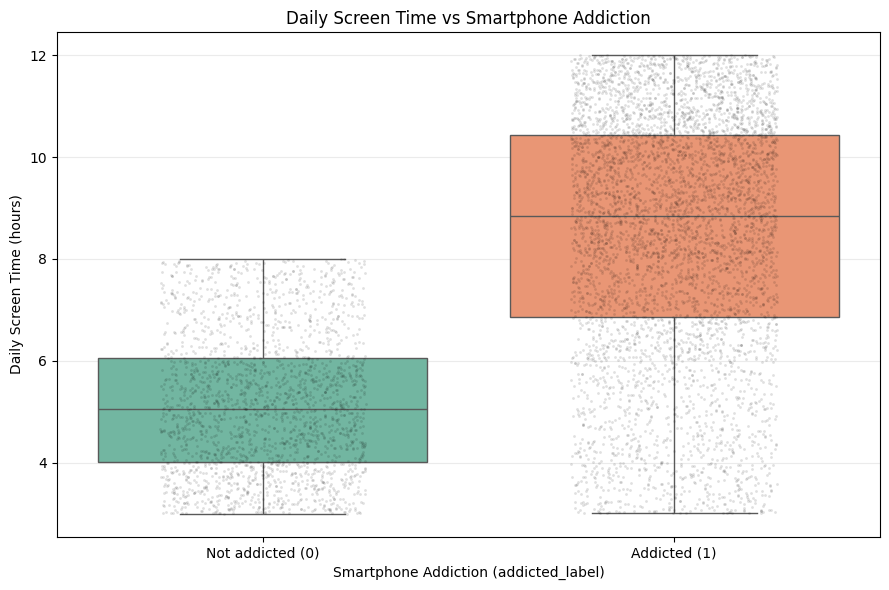

In [43]:
# Graph 1: Daily screen time versus the existing addiction target
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = pd.read_csv("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=plot_df,
    x="addicted_label",
    y="daily_screen_time_hours",
    hue="addicted_label",
    palette="Set2",
    legend=False,
)
sns.stripplot(
    data=plot_df,
    x="addicted_label",
    y="daily_screen_time_hours",
    color="black",
    alpha=0.12,
    size=2,
    jitter=0.25,
)
plt.title("Daily Screen Time vs Smartphone Addiction")
plt.xlabel("Smartphone Addiction (addicted_label)")
plt.ylabel("Daily Screen Time (hours)")
plt.xticks([0, 1], ["Not addicted (0)", "Addicted (1)"])
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

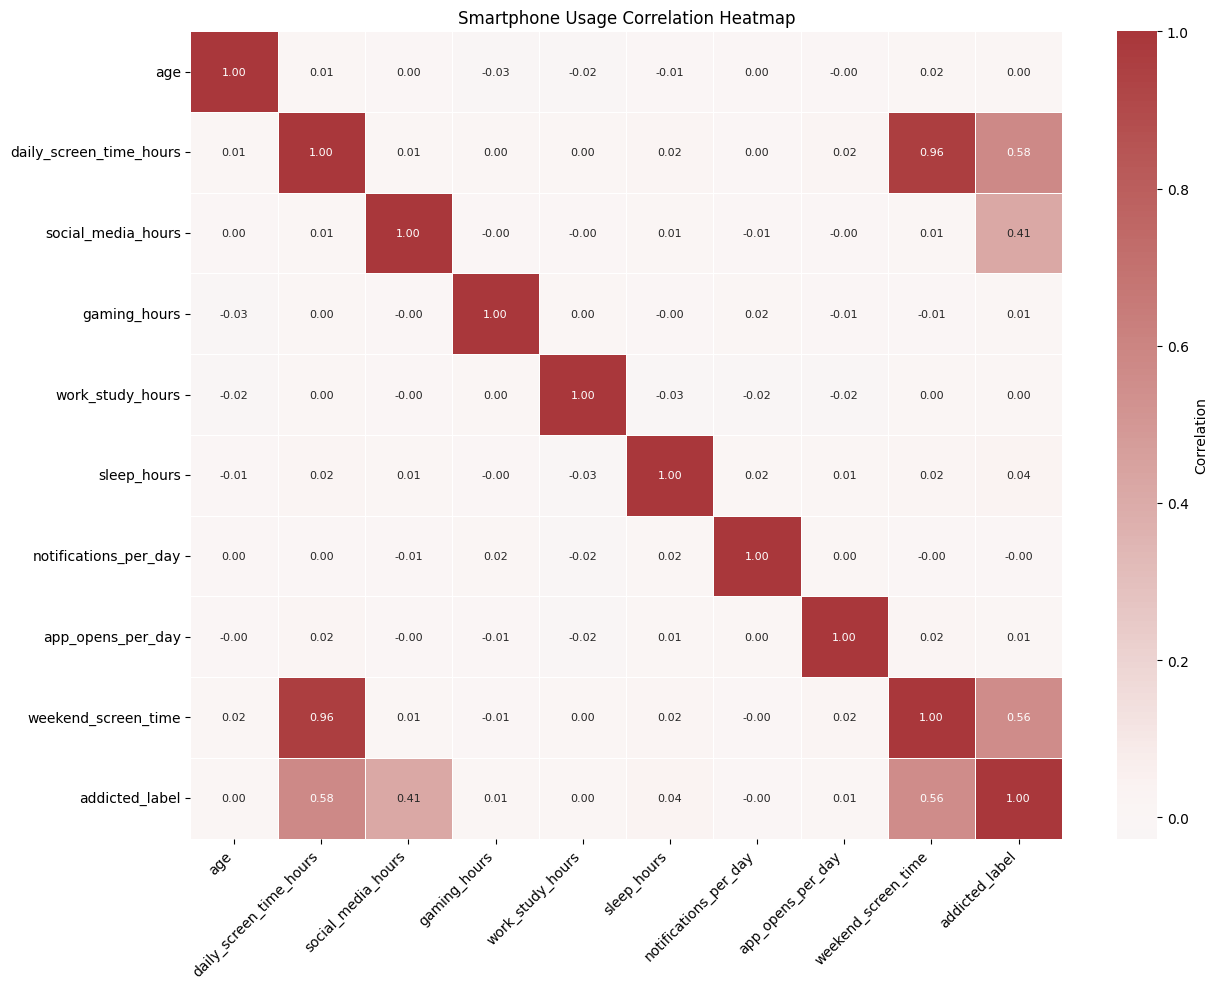

In [44]:
# Graph 2: Correlation heatmap for all numerical dataset columns
numeric_corr = plot_df.select_dtypes(include="number").corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    numeric_corr,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"label": "Correlation"},
)
plt.title("Smartphone Usage Correlation Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
# Gradio UI: use the existing trained DecisionTreeClassifier without retraining
import importlib
import typing_extensions

importlib.reload(typing_extensions)
import gradio as gr

all_input_columns = [
    "age",
    "gender",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time",
    "stress_level",
    "academic_work_impact",
]
model_input_columns = list(clf.feature_names_in_)


def predict_addiction(
    age,
    gender,
    daily_screen_time_hours,
    social_media_hours,
    gaming_hours,
    work_study_hours,
    sleep_hours,
    notifications_per_day,
    app_opens_per_day,
    weekend_screen_time,
    stress_level,
    academic_work_impact,
):
    full_input = pd.DataFrame(
        [[
            age,
            gender,
            daily_screen_time_hours,
            social_media_hours,
            gaming_hours,
            work_study_hours,
            sleep_hours,
            notifications_per_day,
            app_opens_per_day,
            weekend_screen_time,
            stress_level,
            academic_work_impact,
        ]],
        columns=all_input_columns,
    )
    model_input = full_input.loc[:, model_input_columns]
    prediction = clf.predict(model_input)[0]
    if int(prediction) == 0:
        return """📱 Smartphone Addiction Prediction

🟢 Not Addicted

The model predicts that this user does not show
a high smartphone addiction risk based on the
provided usage patterns."""
    return """📱 Smartphone Addiction Prediction

🔴 Addicted

The model predicts that this user shows a high
smartphone addiction risk based on the
provided usage patterns."""


prediction_inputs = [
    gr.Number(label="Age", value=21),
    gr.Dropdown(["Male", "Female", "Other"], label="Gender", value="Male"),
    gr.Number(label="Daily Screen Time (hours)", value=3.23),
    gr.Number(label="Social Media Hours", value=2.01),
    gr.Number(label="Gaming Hours", value=0.89),
    gr.Number(label="Work/Study Hours", value=4.55),
    gr.Number(label="Sleep Hours", value=7.55),
    gr.Number(label="Notifications per Day", value=248),
    gr.Number(label="App Opens per Day", value=154),
    gr.Number(label="Weekend Screen Time (hours)", value=3.95),
    gr.Dropdown(["Low", "Medium", "High"], label="Stress Level", value="Medium"),
    gr.Dropdown(["Yes", "No"], label="Academic Work Impact", value="Yes"),
]

demo = gr.Interface(
    fn=predict_addiction,
    inputs=prediction_inputs,
    outputs=gr.Textbox(label="Prediction"),
    title="Smartphone Addiction Predictor",
    description="Enter all smartphone usage features to predict addicted_label.",
)

sample_prediction = predict_addiction(
    21,
    "Male",
    3.23,
    2.01,
    0.89,
    4.55,
    7.55,
    248,
    154,
    3.95,
    "Medium",
    "Yes",
)
print(f"All UI columns: {all_input_columns}")
print(f"Columns used by existing clf: {model_input_columns}")
print(sample_prediction)

demo.launch(inline=True, share=False, prevent_thread_lock=True)

All UI columns: ['age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time', 'stress_level', 'academic_work_impact']
Columns used by existing clf: ['age', 'daily_screen_time_hours', 'sleep_hours']
📱 Smartphone Addiction Prediction

🟢 Not Addicted

The model predicts that this user does not show
a high smartphone addiction risk based on the
provided usage patterns.
* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
